# Exploratory Data Analysis — Nepal Job Market

This notebook performs EDA on the cleaned job listings data from two Nepali job portals (MeroJob & KumariJob).

**Analyses performed:**
1. Basic statistics overview
2. Top 15 job categories
3. Job distribution by city
4. Job level distribution
5. Salary distribution
6. Top 20 in-demand skills
7. Source comparison (MeroJob vs KumariJob)
8. Salary range by job category

> **Prerequisite:** Run `python scheduler.py` at least once so that `jobs.db` contains data.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

## 1. Load Data from SQLite

In [2]:
DB_PATH = "jobs.db"

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM jobs_clean", conn)
conn.close()

# Coerce types
df['salary_min'] = pd.to_numeric(df['salary_min'], errors='coerce')
df['salary_max'] = pd.to_numeric(df['salary_max'], errors='coerce')
df['scraped_at'] = pd.to_datetime(df['scraped_at'], errors='coerce')

print(f"Loaded {len(df)} jobs from database")
print(f"Sources: {df['source'].value_counts().to_dict()}")
print(f"Date range: {df['scraped_at'].min()} to {df['scraped_at'].max()}")
df.head()

Loaded 1163 jobs from database
Sources: {'merojob': 840, 'kumarijob': 323}
Date range: 2026-02-10 20:19:26 to 2026-03-11 21:25:02


,source,job_id,title,company,location,category,job_level,skills,salary_min,salary_max,currency,deadline,scraped_at,job_url,experience,education,scrape_date
0,merojob,mj_196756,Electrical Engineer,CTEX Import & Export,"Jhamshikhel-03, Lalitpur","Construction / Engineering / Architects, CAD/ ...",Mid Level,"Work Under Pressure, Fast Learner, Troubleshoo...",15000.0,25000.0,NRs,2026-02-21,2026-02-10 20:19:26,https://www.merojob.com/technical-head-officer/,N/A,N/A,2026-02-10
1,merojob,mj_198103,Cloud Specialist,Simjung,Naxal,IT & Telecommunication,Mid Level,"Technical, Collaboration, Automation, Strategi...",50000.0,60000.0,NRs,2026-02-25,2026-02-10 20:19:26,https://www.merojob.com/cloud-specialist/,N/A,N/A,2026-02-10
2,merojob,mj_197751,Preschool Teacher,Sano Paila Daycare and Early Learning Center,"Imadol, Ochu height","Teaching / Education, Early childhood care and...",Entry Level,"Communication, Monitoring, Montessori Teaching...",20000.0,25000.0,NRs,2026-02-25,2026-02-10 20:19:26,https://www.merojob.com/pre-school-teacher-112/,N/A,N/A,2026-02-10
3,merojob,mj_198092,Education And Visa Counselor,Kharel Law Group,"Lazimpat, Kathmandu",Education Counseling / Career Counseling,Mid Level,"Communication, Counseling, Documentation, Lega...",30000.0,35000.0,NRs,2026-02-25,2026-02-10 20:19:26,https://www.merojob.com/education-and-visa-cou...,N/A,N/A,2026-02-10
4,merojob,mj_198089,Asstistant Handicraft Factory Manager,Felt and Yarn,"Puspalal Path-16, Nayabazzar, Kathmandu, Nepal","General Mgmt. / Administration / Operations, A...",Mid Level,"Communication, Analytical, Administration, Mar...",25000.0,40000.0,NRs,2026-02-25,2026-02-10 20:19:26,https://www.merojob.com/asst-handicraft-factor...,N/A,N/A,2026-02-10


## 2. Basic Statistics Overview

In [3]:
print("=" * 55)
print("  BASIC STATISTICS")
print("=" * 55)
print(f"  Total job listings      : {len(df)}")
print(f"  Unique companies        : {df['company'].nunique()}")
print(f"  Unique job categories   : {df['category'].nunique()}")
print(f"  Unique locations        : {df['location'].nunique()}")
print(f"  Jobs with salary info   : {df['salary_min'].notna().sum()}")
if df['salary_min'].notna().any():
    print(f"  Average salary (min)    : NPR {df['salary_min'].mean():,.0f}")
    print(f"  Median  salary (min)    : NPR {df['salary_min'].median():,.0f}")
print()
print("Missing values per column:")
df.isnull().sum()

  BASIC STATISTICS
  Total job listings      : 1163
  Unique companies        : 561
  Unique job categories   : 305
  Unique locations        : 429
  Jobs with salary info   : 980
  Average salary (min)    : NPR 29,650
  Median  salary (min)    : NPR 28,500

Missing values per column:


source           0
job_id           0
title            0
company          0
location         0
category         0
job_level        0
skills           0
salary_min     183
salary_max     387
currency         0
deadline         0
scraped_at       0
job_url          0
experience       0
education        0
scrape_date      0
dtype: int64

## 3. Top 15 Job Categories

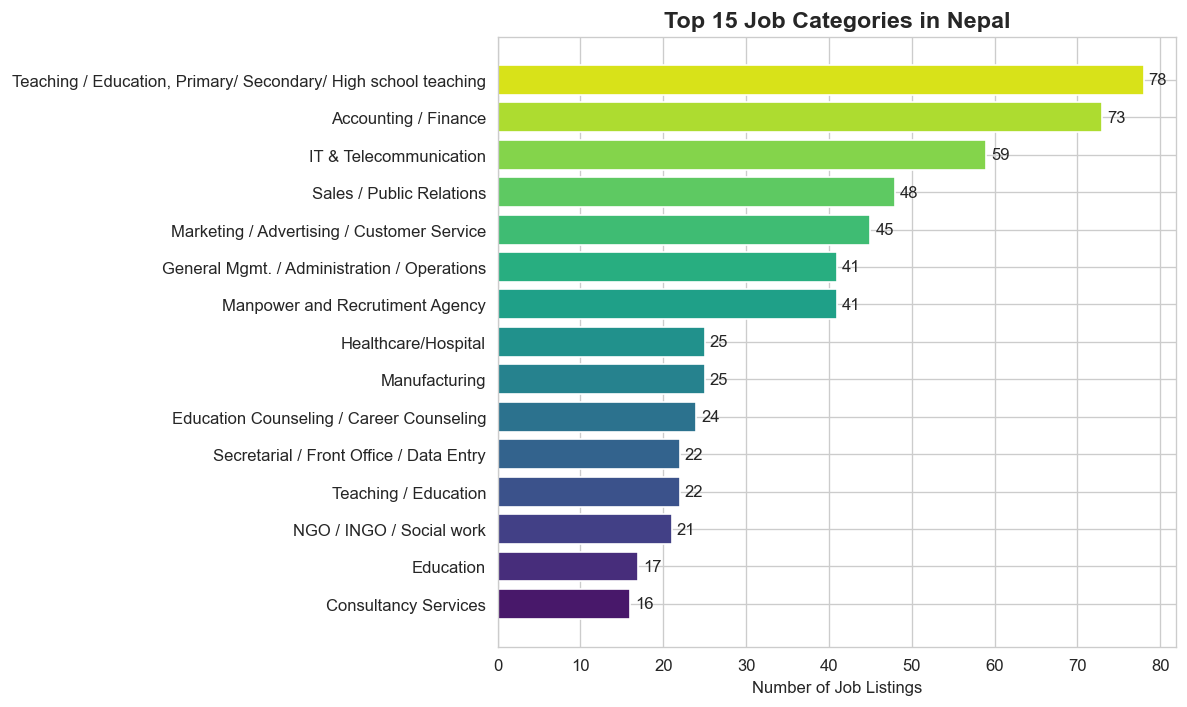

In [11]:
cat_counts = df['category'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color=sns.color_palette("viridis", len(cat_counts)))
ax.bar_label(bars, padding=3)
ax.set_xlabel("Number of Job Listings")
ax.set_title("Top 15 Job Categories in Nepal", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Job Distribution by City (Donut Chart)

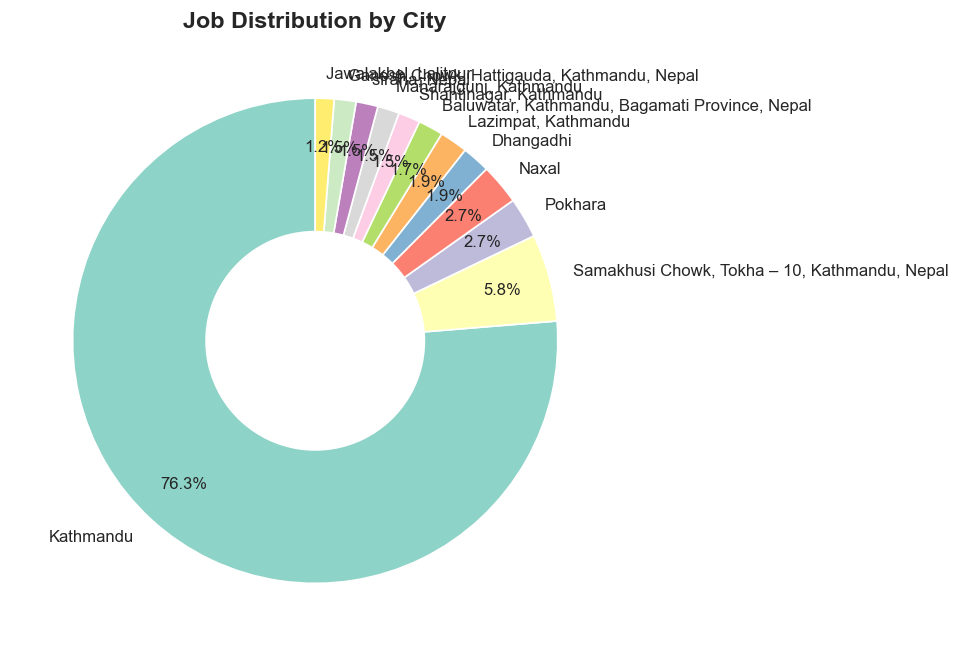

In [12]:
loc_counts = df[df['location'] != 'Unknown']['location'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(8, 8))
colors = sns.color_palette("Set3", len(loc_counts))
wedges, texts, autotexts = ax.pie(
    loc_counts.values, labels=loc_counts.index, autopct='%1.1f%%',
    colors=colors, pctdistance=0.8, startangle=90,
    wedgeprops=dict(width=0.55)  # donut
)
ax.set_title("Job Distribution by City", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Job Level Distribution

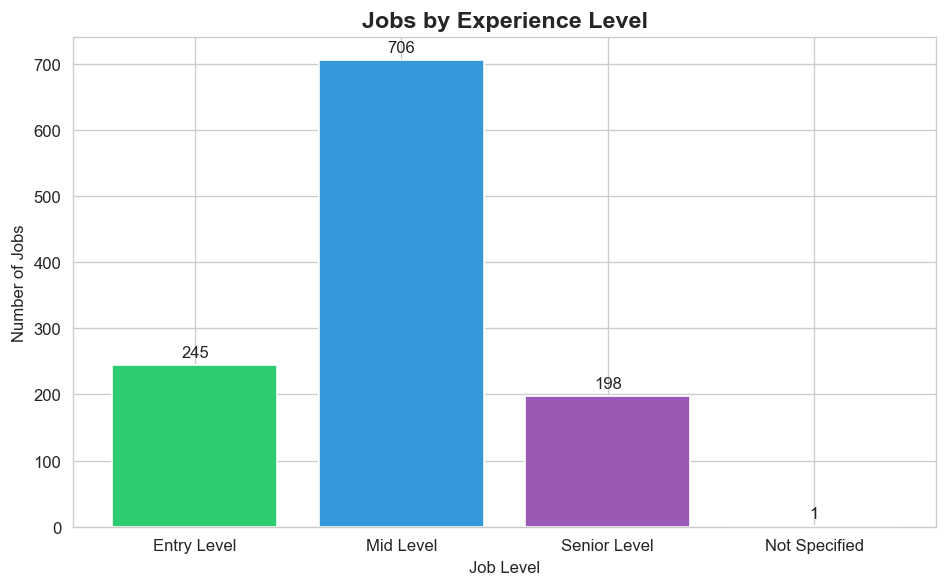

In [13]:
level_order = ['Entry Level', 'Mid Level', 'Senior Level', 'Management', 'Not Specified']
level_counts = df['job_level'].value_counts()
level_counts = level_counts.reindex([l for l in level_order if l in level_counts.index])

color_map = {
    'Entry Level': '#2ecc71', 'Mid Level': '#3498db',
    'Senior Level': '#9b59b6', 'Management': '#e74c3c', 'Not Specified': '#95a5a6'
}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(level_counts.index, level_counts.values,
              color=[color_map.get(l, '#aaa') for l in level_counts.index])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Job Level")
ax.set_ylabel("Number of Jobs")
ax.set_title("Jobs by Experience Level", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Salary Distribution (Histogram with KDE)

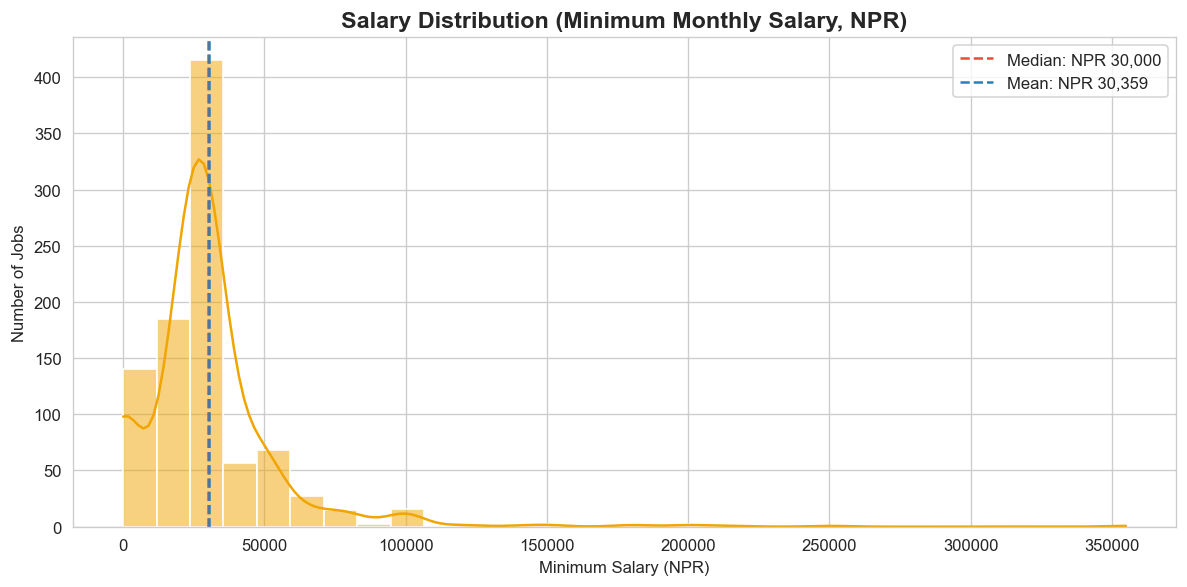

In [14]:
salary_df = df[(df['salary_min'].notna()) & (df['salary_min'] > 0) & (df['salary_min'] < 500_000)]

if len(salary_df) > 5:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(salary_df['salary_min'], bins=30, kde=True, color='#f0a500', ax=ax)
    median_sal = salary_df['salary_min'].median()
    mean_sal = salary_df['salary_min'].mean()
    ax.axvline(median_sal, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Median: NPR {median_sal:,.0f}')
    ax.axvline(mean_sal, color='#2980b9', linestyle='--', linewidth=1.5, label=f'Mean: NPR {mean_sal:,.0f}')
    ax.set_xlabel("Minimum Salary (NPR)")
    ax.set_ylabel("Number of Jobs")
    ax.set_title("Salary Distribution (Minimum Monthly Salary, NPR)", fontsize=14, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Not enough salary data (< 5 entries)")

## 7. Top 20 In-Demand Skills

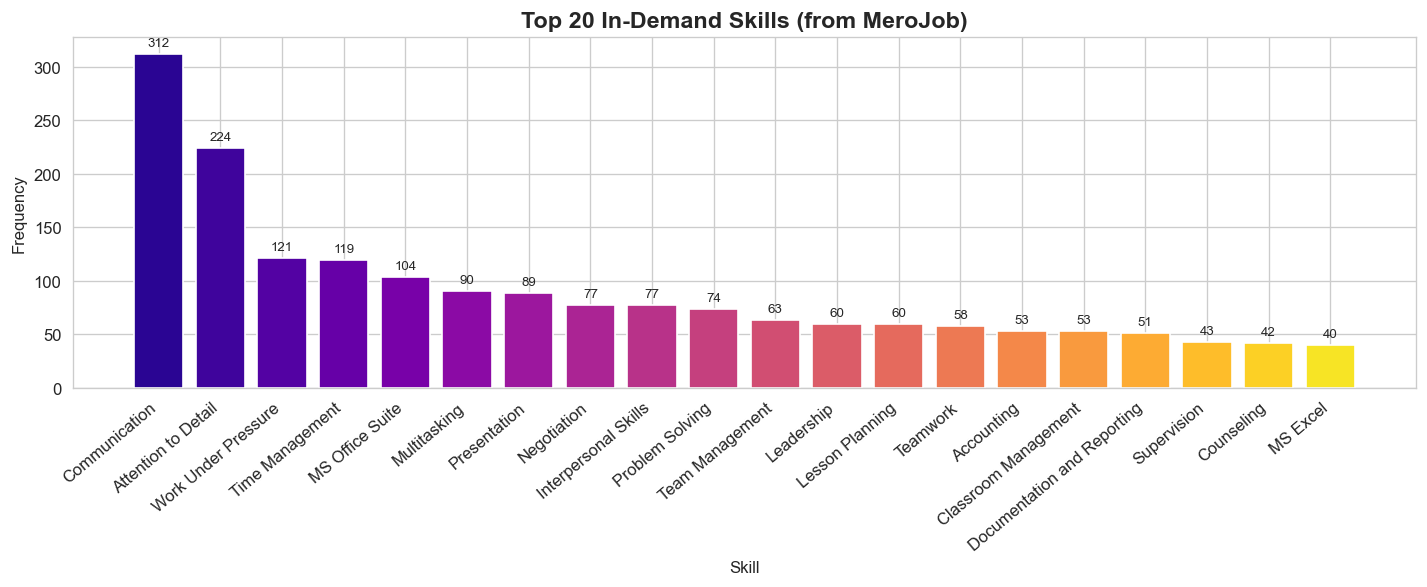

In [15]:
all_skills = []
for skills_str in df['skills'].dropna():
    if skills_str and skills_str.strip():
        for skill in skills_str.split(','):
            skill = skill.strip()
            if skill and skill.lower() not in ('n/a', 'na', ''):
                all_skills.append(skill)

if len(all_skills) > 10:
    skill_counts = pd.Series(Counter(all_skills)).sort_values(ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(skill_counts.index, skill_counts.values, color=sns.color_palette("plasma", len(skill_counts)))
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.set_xlabel("Skill")
    ax.set_ylabel("Frequency")
    ax.set_title("Top 20 In-Demand Skills (from MeroJob)", fontsize=14, fontweight='bold')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough skills data.")

## 8. Source Comparison — MeroJob vs KumariJob

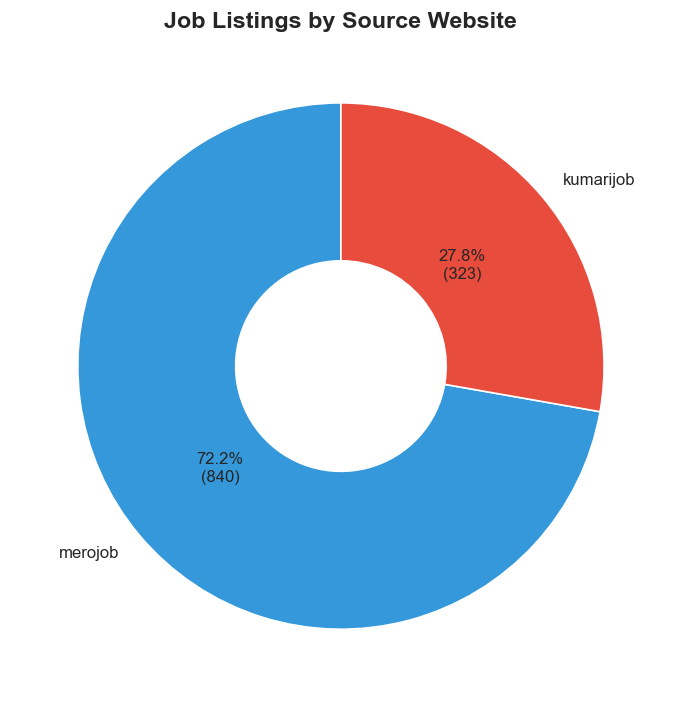

In [16]:
source_counts = df['source'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
colors = {'merojob': '#3498db', 'kumarijob': '#e74c3c'}
ax.pie(
    source_counts.values, labels=source_counts.index,
    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(source_counts.values)/100)})',
    colors=[colors.get(s, '#aaa') for s in source_counts.index],
    startangle=90, wedgeprops=dict(width=0.6)
)
ax.set_title("Job Listings by Source Website", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Salary Range by Job Category (Box Plot)

C:\Users\User\AppData\Local\Temp\ipykernel_12632\1480392605.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sal_cat, x='category', y='salary_min',


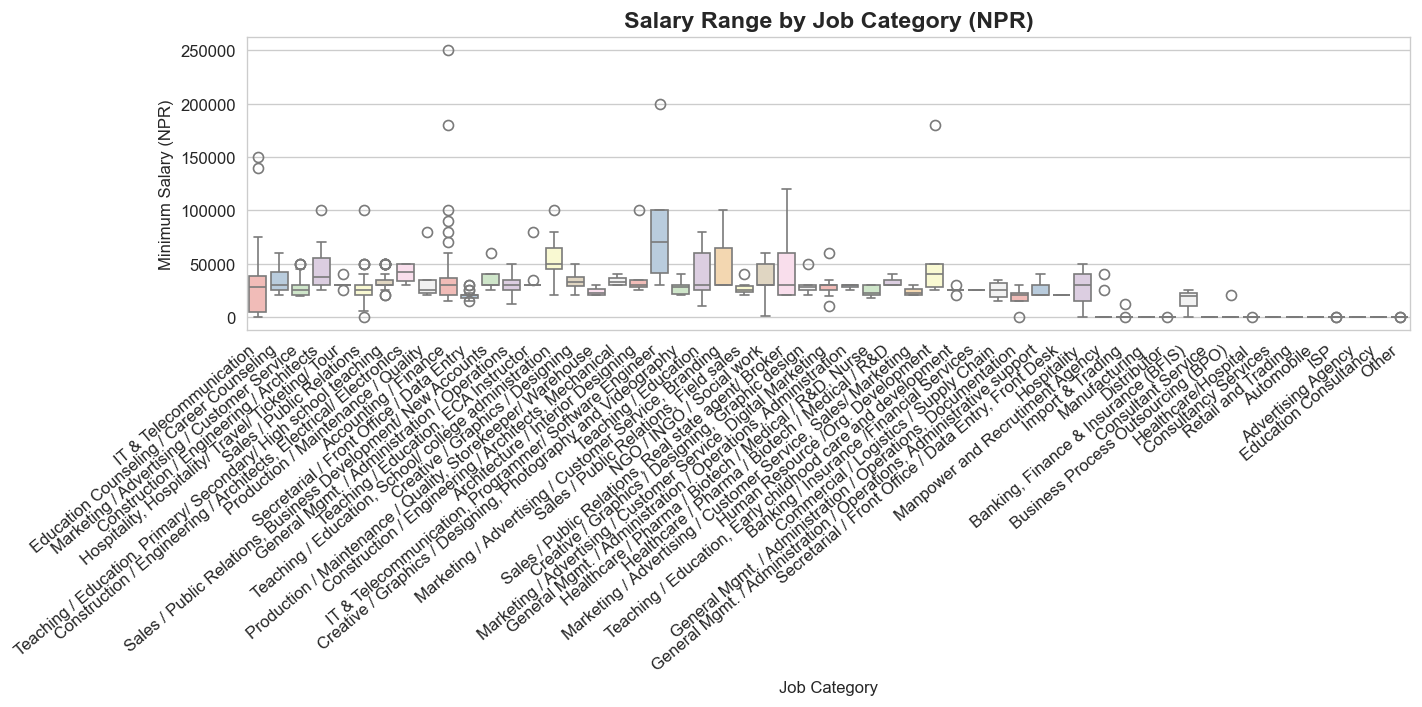

In [17]:
sal_cat = df[(df['salary_min'].notna()) & (df['salary_min'] > 0) & (df['salary_min'] < 300_000)]

# Keep categories with at least 3 salary entries
valid_cats = sal_cat['category'].value_counts()
valid_cats = valid_cats[valid_cats >= 3].index.tolist()
sal_cat = sal_cat[sal_cat['category'].isin(valid_cats)]

if len(sal_cat) > 10:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=sal_cat, x='category', y='salary_min',
                palette='Pastel1', ax=ax)
    ax.set_xlabel("Job Category")
    ax.set_ylabel("Minimum Salary (NPR)")
    ax.set_title("Salary Range by Job Category (NPR)", fontsize=14, fontweight='bold')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough salary+category data for box plot")

---
## EDA Complete

All 7 analyses have been performed and visualized inline above.